In [1]:
import torch
import torch.nn as nn

#### Testing loading the COCO DATASET from torch
- Creating it's sub dataset as well for testing the architecture built on the go

In [1]:
import json
import os
import shutil
from pathlib import Path

# Paths
src_images = r'c:\Projects\DETR from srcatch\val2017'
src_annotations = r'c:\Projects\DETR from srcatch\val2017_annotations\annotations\instances_val2017.json'
dst_base = r'c:\Projects\DETR from srcatch\coco_mini'
dst_images = os.path.join(dst_base, 'images')
dst_annotations = os.path.join(dst_base, 'annotations.json')

# Create directories
os.makedirs(dst_images, exist_ok=True)

# Load annotations
with open(src_annotations, 'r') as f:
    annotations = json.load(f)

# Get all image IDs
all_images = annotations['images']
print(f'Total images in dataset: {len(all_images)}')

# Take first 100 images
selected_images = all_images[:100]
selected_image_ids = set(img['id'] for img in selected_images)
print(f'Selected {len(selected_images)} images')

# Copy selected images
copied = 0
for img_info in selected_images:
    filename = img_info['file_name']
    src_path = os.path.join(src_images, filename)
    if os.path.exists(src_path):
        shutil.copy2(src_path, os.path.join(dst_images, filename))
        copied += 1
print(f'Copied {copied} images')

# Filter annotations to only include selected images
filtered_images = selected_images.copy()
filtered_annotations = [ann for ann in annotations['annotations'] if ann['image_id'] in selected_image_ids]

# Create filtered JSON
filtered_data = {
    'images': filtered_images,
    'annotations': filtered_annotations,
    'categories': annotations.get('categories', [])
}

# Save annotations
with open(dst_annotations, 'w') as f:
    json.dump(filtered_data, f)

print(f'Saved annotations with {len(filtered_images)} images and {len(filtered_annotations)} annotations')

Total images in dataset: 5000
Selected 100 images
Copied 100 images
Saved annotations with 100 images and 658 annotations


coco_mini/
├── annotations.json    # Filtered COCO annotations (images + annotations + categories)
└── images/            # 100 JPEG images
    ├── 000000000139.jpg
    ├── 000000000285.jpg
    └── ... (98 more)

In [5]:
# %pip install opencv-python

In [15]:
import json
import cv2
import random
import matplotlib.pyplot as plt
%matplotlib notebook
%matplotlib inline
# Load annotation
with open("coco_mini/annotations.json") as f:
    coco = json.load(f)

str(coco)[:500]

"{'images': [{'license': 4, 'file_name': '000000397133.jpg', 'coco_url': 'http://images.cocodataset.org/val2017/000000397133.jpg', 'height': 427, 'width': 640, 'date_captured': '2013-11-14 17:02:52', 'flickr_url': 'http://farm7.staticflickr.com/6116/6255196340_da26cf2c9e_z.jpg', 'id': 397133}, {'license': 1, 'file_name': '000000037777.jpg', 'coco_url': 'http://images.cocodataset.org/val2017/000000037777.jpg', 'height': 230, 'width': 352, 'date_captured': '2013-11-14 20:55:31', 'flickr_url': 'http"

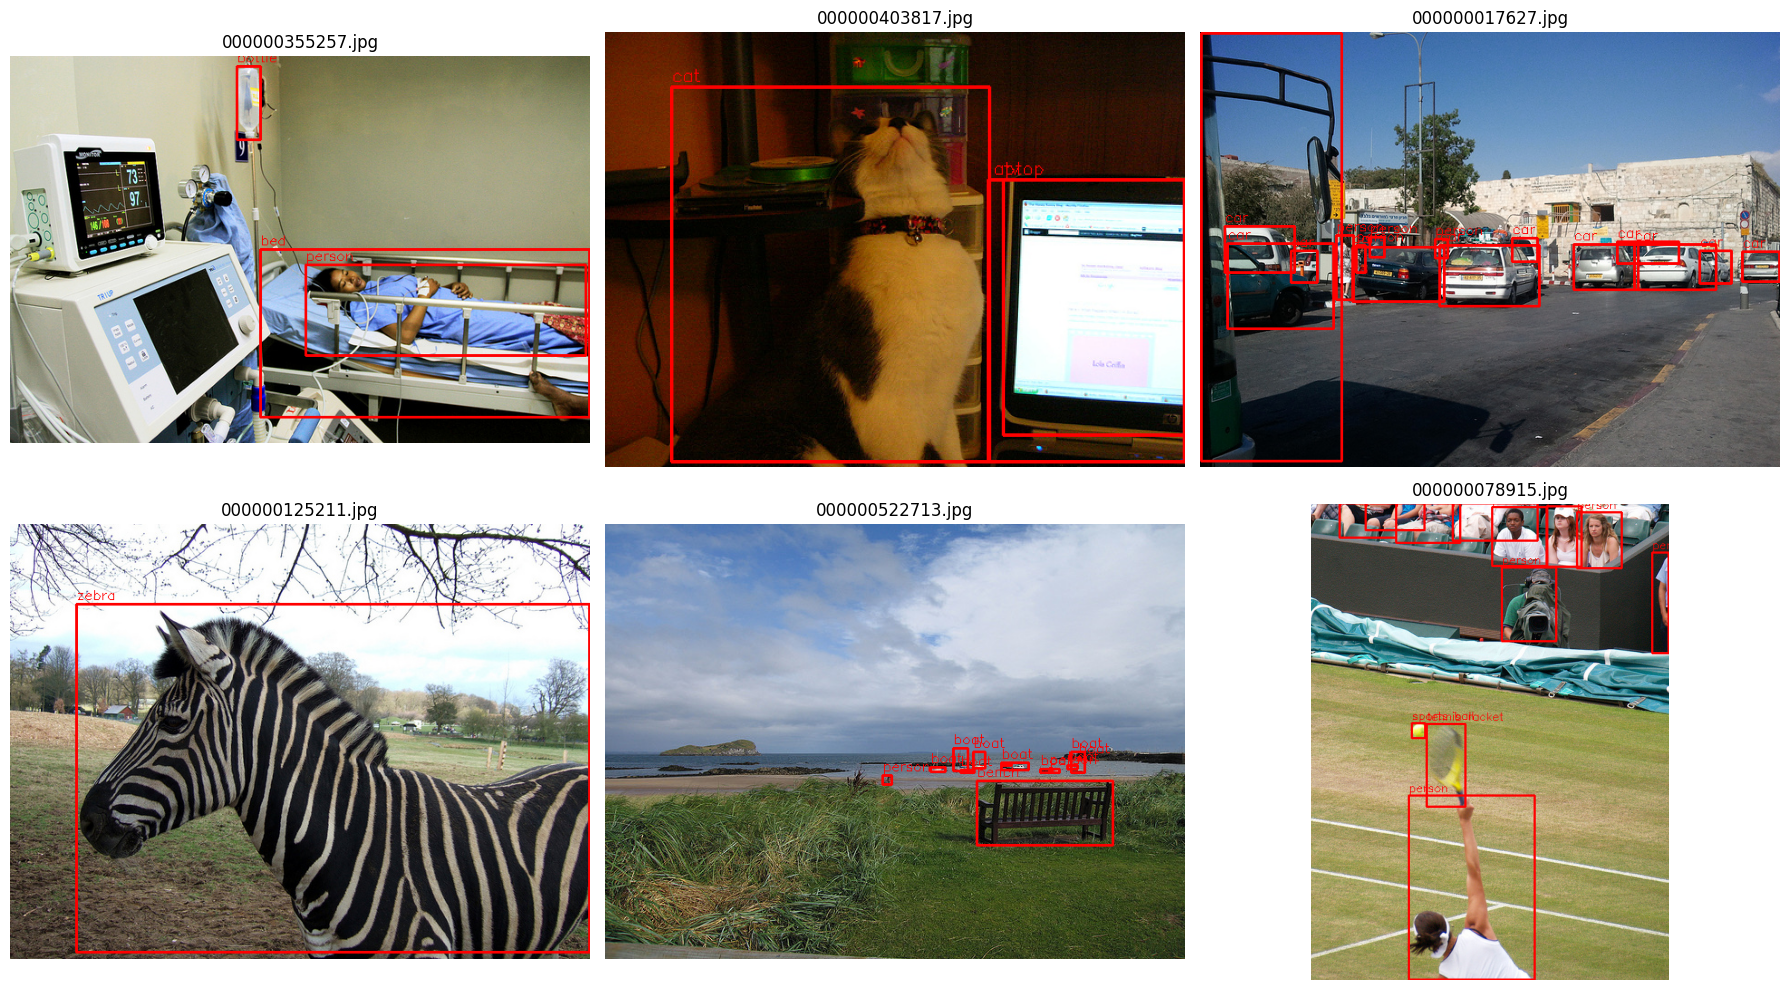

In [16]:
# Enable interactive zoom (important)
# %matplotlib widget
plt.ion()

# Build mappings
id_to_image = {img["id"]: img for img in coco["images"]}
cat_id_to_name = {cat["id"]: cat["name"] for cat in coco["categories"]}

# Group annotations by image
image_to_anns = {}
for ann in coco["annotations"]:
    image_to_anns.setdefault(ann["image_id"], []).append(ann)

# Pick 6 random images
image_ids = random.sample(list(image_to_anns.keys()), 6)

# Create subplot grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, image_id in enumerate(image_ids):
    image_info = id_to_image[image_id]

    # Load image
    img_path = f'coco_mini/images/{image_info["file_name"]}'
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Draw boxes
    for ann in image_to_anns[image_id]:
        x, y, w, h = ann["bbox"]
        x, y, w, h = map(int, [x, y, w, h])

        cv2.rectangle(image, (x, y), (x + w, y + h), (255, 0, 0), 2)

        label = cat_id_to_name[ann["category_id"]]
        cv2.putText(image, label, (x, max(0, y - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

    # Plot
    axes[idx].imshow(image)
    axes[idx].set_title(image_info["file_name"])
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

# Keep window open for zoom interaction
plt.ioff()

### Testing creating base DETR Model

Image → Backbone → Transformer → Object Queries → Predictions

 creating the backbone

In [4]:
import torch
import torch.nn as nn
from torchvision import models


In [5]:
backbone = models.resnet50(pretrained = True)
backbone.fc
# backbone = nn.Sequential()

c:\Projects\testenv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Projects\testenv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Linear(in_features=2048, out_features=1000, bias=True)

In [6]:
backbone = nn.Sequential(*list(backbone.children())[:-2])
backbone[-1]

Sequential(
  (0): Bottleneck(
    (conv1): Conv2d(1024, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv3): Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn3): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (downsample): Sequential(
      (0): Conv2d(1024, 2048, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (1): Bottleneck(
    (conv1): Conv2d(2048, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): 

In [7]:
list(list(backbone.children())[-1])[-1].bn3.num_features

2048

- Projecting to transformer dimension

In [8]:
import torch
from torch import nn
import math

class PositionalEncoding2D(nn.Module):
    def __init__(self, d_model=256, temperature=10000):
        super().__init__()
        self.d_model = d_model
        self.temperature = temperature
        # DETR splits d_model in half: 128 for Y, 128 for X
        self.num_pos_feats = d_model // 2 

    def forward(self, x):
        # x shape: [B, C, H, W]
        b, c, h, w = x.shape
        device = x.device
        
        # 1. Create a coordinate grid (0 to H-1 and 0 to W-1)
        y_embed = torch.arange(1, h + 1, device=device).float()
        x_embed = torch.arange(1, w + 1, device=device).float()

        # 2. Create the scale/frequency terms
        dim_t = torch.arange(self.num_pos_feats, device=device).float()
        dim_t = self.temperature ** (2 * (dim_t // 2) / self.num_pos_feats)

        # 3. Divide embeddings by frequencies
        # Result shapes: [H, num_pos_feats] and [W, num_pos_feats]
        pos_y = y_embed[:, None] / dim_t
        pos_x = x_embed[:, None] / dim_t

        # 4. Apply Sin to even indices and Cos to odd indices
        pos_y = torch.stack((pos_y[:, 0::2].sin(), pos_y[:, 1::2].cos()), dim=2).flatten(1)
        pos_x = torch.stack((pos_x[:, 0::2].sin(), pos_x[:, 1::2].cos()), dim=2).flatten(1)

        # 5. Broadcast and combine
        # pos_y: [H, W, 128], pos_x: [H, W, 128]
        pos_y = pos_y.view(h, 1, self.num_pos_feats).repeat(1, w, 1)
        pos_x = pos_x.view(1, w, self.num_pos_feats).repeat(h, 1, 1)

        # Final shape: [B, 256, H, W]
        pos = torch.cat((pos_y, pos_x), dim=2).permute(2, 0, 1).unsqueeze(0).repeat(b, 1, 1, 1)
        
        return pos


In [9]:
pos = PositionalEncoding2D()
x = torch.rand([1,3,12,12])
pe = pos(x)
pe.shape

torch.Size([1, 256, 12, 12])

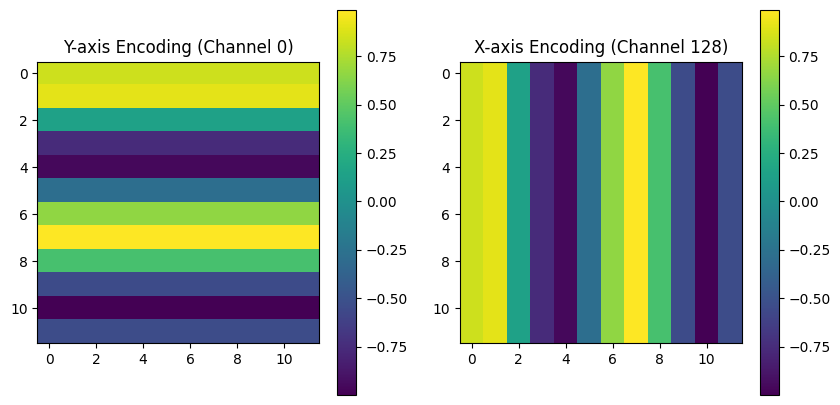

In [10]:
import matplotlib.pyplot as plt
# pe_tensor = pe[0] if isinstance(pe, tuple) else pe
# 2. Extract a few channels to visualize
# We'll grab the 1st channel (Y-axis encoding) and the 129th channel (X-axis encoding)
y_sample = pe[0, 0, :, :].detach().numpy()    # First half represents Y
x_sample = pe[0, 128, :, :].detach().numpy()  # Second half represents X

# 3. Plotting
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

im1 = axes[0].imshow(y_sample, cmap='viridis')
axes[0].set_title("Y-axis Encoding (Channel 0)")
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(x_sample, cmap='viridis')
axes[1].set_title("X-axis Encoding (Channel 128)")
plt.colorbar(im2, ax=axes[1])

plt.show()

In [45]:
class DETRwithTransformerModule(nn.Module):
    def __init__(self, d_model = 256, pred_classes = 100, debug = True,dropout = 0.0):
        super().__init__()
        self.d_model = d_model
        self.backbone =  models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(self.backbone.children())[:-2])
        # print(list(self.backbone.children())[-1])
        # print('------')
        self.in_channel = list(list(self.backbone.children())[-1])[-1].bn3.num_features
        self.conversion_convlutional_layer = nn.Conv2d(self.in_channel, d_model, kernel_size=1)
        self.pe = PositionalEncoding2D()

        self.transformer = nn.Transformer(d_model=self.d_model,
                                          num_encoder_layers=2,
                                          num_decoder_layers=2,
                                          dropout=dropout
                                        #   batch_first=True
                                          )
        self.object_queries = nn.Parameter(torch.empty(100,256),requires_grad=True)
        nn.init.xavier_uniform_(self.object_queries)

        self.pred_class = nn.Linear(d_model, pred_classes+1,)
        self.bbox = nn.Sequential(
                nn.Linear(d_model, d_model),
                nn.ReLU(),
                nn.Linear(d_model, 4),
                nn.Sigmoid()
            )
        self.debug = debug

    def forward(self, x):
        
        x = self.backbone(x)
        if self.debug:
            print("Shape after passing through backbone : ",x.shape)
        x = self.conversion_convlutional_layer(x)
        if self.debug:
            print(f"Shape after passing through the Conversion channel before feeding to Transformer : ", x.shape)
        b,c,H,W = x.shape
        # print(b,H,c,W)
        # adding positional encoding
        positional = self.pe(x)
        # print(positional.shape,x.shape)
        x = x + positional

        # post positional encoding adding, flattening it
        if self.debug:
            print(x.shape)
        # changing shape from (batch, embedding dimensions, pixels) -> (pixels, batch, embedding_dimensions)
        x = x.flatten(2,3).permute(2,0,1)#.permute(0,2,1)#.permute(2,0,1)


        if self.debug:
            print("Shape of x after flatteining, [sequence, batch,  dimension]", x.shape)
        # self.object_queries = self.object_queries.unsqueeze(0)#.repeat(1,b,1)
            print(f"Shape of object queries : ", self.object_queries.shape)

        query_embed = self.object_queries.unsqueeze(1).repeat(1,b,1)
        tgt = torch.zeros_like(query_embed)

        hs = self.transformer(x, tgt)  #.permute(1,0,2)
        hs = hs + query_embed
        hs = hs.permute(1,0,2)

        if self.debug:
            print("Shape of the transformer operation Output : ", hs.shape)

        class_pred = self.pred_class(hs)
        bbox_pred = self.bbox(hs)#.sigmoid()
        if self.debug:
            print(f"Class Pred shape : ", class_pred.shape)
            print(f"Bounding Box shape : ", bbox_pred.shape)
        
        outputs = {
                "pred_logits": class_pred,   # [B, Q, C+1]
                "pred_boxes": bbox_pred      # [B, Q, 4] (cx, cy, w, h normalized)
            }
        return outputs
        

        


    

In [46]:
batch_size = 2
device = 'cuda' if torch.cuda.is_available() else 'cpu'
x = torch.rand([batch_size,3,256,256])
model = DETRwithTransformerModule(debug=False).to(device)
# model(x.to(device))

c:\Projects\testenv\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [47]:
import torchinfo

torchinfo.summary(model=model, input_size=(1,3,256,256))

Layer (type:depth-idx)                                  Output Shape              Param #
DETRwithTransformerModule                               [1, 100, 4]               25,600
├─Sequential: 1-1                                       [1, 2048, 8, 8]           --
│    └─Conv2d: 2-1                                      [1, 64, 128, 128]         9,408
│    └─BatchNorm2d: 2-2                                 [1, 64, 128, 128]         128
│    └─ReLU: 2-3                                        [1, 64, 128, 128]         --
│    └─MaxPool2d: 2-4                                   [1, 64, 64, 64]           --
│    └─Sequential: 2-5                                  [1, 256, 64, 64]          --
│    │    └─Bottleneck: 3-1                             [1, 256, 64, 64]          75,008
│    │    └─Bottleneck: 3-2                             [1, 256, 64, 64]          70,400
│    │    └─Bottleneck: 3-3                             [1, 256, 64, 64]          70,400
│    └─Sequential: 2-6                  

## Working on creating  Bipatriate Matching
- READING DATASET SAMPLE 1
- BUILDING MATCHING AROUND IT

In [48]:
import json
import cv2
import random
import matplotlib.pyplot as plt
%matplotlib notebook
%matplotlib inline
# Load annotation
with open("coco_mini/annotations.json") as f:
    coco = json.load(f)

In [49]:
# Build mappings
id_to_image = {img["id"]: img for img in coco["images"]}
cat_id_to_name = {cat["id"]: cat["name"] for cat in coco["categories"]}

# Group annotations by image
image_to_anns = {}
for ann in coco["annotations"]:
    image_to_anns.setdefault(ann["image_id"], []).append(ann)

# Pick 6 random images
image_ids = random.sample(list(image_to_anns.keys()), 6)

len(coco['annotations']),coco['annotations'][0]

(658,
 {'segmentation': [[110.39,
    135.78,
    110.39,
    127.62,
    110.01,
    119.6,
    106.87,
    118.47,
    104.37,
    120.1,
    102.49,
    122.73,
    103.74,
    125.49,
    105.24,
    128.88,
    106.87,
    132.39,
    107.38,
    135.78,
    110.39,
    135.65]],
  'area': 88.52115000000006,
  'iscrowd': 0,
  'image_id': 37777,
  'bbox': [102.49, 118.47, 7.9, 17.31],
  'category_id': 64,
  'id': 22328})

In [50]:
image_id = image_ids[0]
image_info = id_to_image[image_id]
anns = image_to_anns[image_id]

print(image_info)
print(len(anns))

{'license': 3, 'file_name': '000000181666.jpg', 'coco_url': 'http://images.cocodataset.org/val2017/000000181666.jpg', 'height': 425, 'width': 640, 'date_captured': '2013-11-16 13:58:29', 'flickr_url': 'http://farm3.staticflickr.com/2572/4127484314_23525e6e9c_z.jpg', 'id': 181666}
16


In [51]:
boxes = []
labels = []

for ann in anns:
    x, y, w, h = ann["bbox"]
    boxes.append([x, y, w, h])
    labels.append(ann["category_id"])

boxes = torch.tensor(boxes, dtype=torch.float32)
labels = torch.tensor(labels, dtype=torch.long)
print(boxes, labels)

tensor([[168.3600, 303.1800,  47.3300, 115.5800],
        [273.5400, 267.8100,  78.0300, 143.1900],
        [340.0000, 276.0200,  88.6600, 116.0800],
        [429.0300, 299.4300,  65.5300, 106.5200],
        [272.5000, 165.8900,  52.3800, 103.9300],
        [ 51.3900, 189.4700,  24.0800,  26.2700],
        [  0.0000, 182.7100,  15.8600,  78.3500],
        [538.9400, 291.7800,  56.3300, 114.6300],
        [468.5100, 255.5100,  34.7100,  32.3800],
        [441.6500, 265.8800,  21.5800,  32.2700],
        [  0.0000, 284.9100,  27.3000,  87.1200],
        [219.0900, 314.3600,  52.8800, 110.6400],
        [458.7600, 213.7100,  45.1800,  29.0400],
        [ 78.9200, 288.4300,  73.8100, 121.8400],
        [600.2900, 279.9800,  39.7100, 103.5200],
        [481.1100, 299.6900,  73.7200, 103.5600]]) tensor([20, 20, 20, 20,  1,  1,  1, 20, 20, 20, 20, 20, 20, 20, 20, 20])


In [52]:
cat_id_to_name[20],cat_id_to_name[1]

('sheep', 'person')

In [53]:
# normalising cordinates as per DETR requirements
def convert_boxes(boxes, img_w, img_h):
    x, y, w, h = boxes.unbind(1)

    cx = (x + 0.5 * w) / img_w
    cy = (y + 0.5 * h) / img_h
    w = w / img_w
    h = h / img_h

    return torch.stack([cx, cy, w, h], dim=1)

boxes = convert_boxes(boxes, image_info["width"], image_info["height"])

In [ ]:
def box_cxcywh_to_xyxy(x):
    cx, cy, w, h = x.unbind(-1)
    x1 = cx - 0.5 * w
    y1 = cy - 0.5 * h
    x2 = cx + 0.5 * w
    y2 = cy + 0.5 * h
    return torch.stack([x1, y1, x2, y2], dim=-1)


from torchvision.ops import generalized_box_iou
from scipy.optimize import linear_sum_assignment

class HungarianMatcher:
    def __init__(self, cost_class=1, cost_bbox=5, cost_giou=2):
        self.cost_class = cost_class
        self.cost_bbox = cost_bbox
        self.cost_giou = cost_giou

    @torch.no_grad()
    def __call__(self, outputs, targets):
        bs, num_queries = outputs["pred_logits"].shape[:2]

        # Flatten for convenience
        out_prob = outputs["pred_logits"].softmax(-1)  # [B, Q, C]
        out_bbox = outputs["pred_boxes"]               # [B, Q, 4]

        indices = []

        for b in range(bs):
            prob = out_prob[b]      # [Q, C]
            bbox = out_bbox[b]      # [Q, 4]

            tgt_ids = targets[b]["labels"]
            tgt_bbox = targets[b]["boxes"]

            # --- Classification cost (negative log prob) ---
            cost_class = -prob[:, tgt_ids]

            # --- L1 cost ---
            cost_bbox = torch.cdist(bbox, tgt_bbox, p=1)

            # --- GIoU cost ---
            bbox_xyxy = box_cxcywh_to_xyxy(bbox)
            tgt_xyxy = box_cxcywh_to_xyxy(tgt_bbox)

            cost_giou = -generalized_box_iou(bbox_xyxy, tgt_xyxy)

            # --- Final cost matrix ---
            C = (
                self.cost_class * cost_class +
                self.cost_bbox * cost_bbox +
                self.cost_giou * cost_giou
            )

            C = C.cpu()
            row_ind, col_ind = linear_sum_assignment(C)

            indices.append((
                torch.as_tensor(row_ind, dtype=torch.int64),
                torch.as_tensor(col_ind, dtype=torch.int64)
            ))

        return indices

#### LOSS function building

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class SetCriterion(nn.Module):
    def __init__(self, num_classes, matcher, eos_coef=0.1):
        super().__init__()
        self.num_classes = num_classes
        self.matcher = matcher

        # Weight for "no object" class
        empty_weight = torch.ones(num_classes + 1)
        empty_weight[-1] = eos_coef
        self.register_buffer("empty_weight", empty_weight)

    def forward(self, outputs, targets):
        indices = self.matcher(outputs, targets)

        loss_class = 0
        loss_bbox = 0
        loss_giou = 0

        bs = len(targets)

        for b in range(bs):
            src_idx, tgt_idx = indices[b]

            pred_logits = outputs["pred_logits"][b]
            pred_boxes = outputs["pred_boxes"][b]

            tgt_labels = targets[b]["labels"]
            tgt_boxes = targets[b]["boxes"]

            # --- Classification target ---
            target_classes = torch.full(
                (pred_logits.shape[0],),
                self.num_classes,
                dtype=torch.long,
                device=pred_logits.device
            )

            target_classes[src_idx] = tgt_labels[tgt_idx]

            loss_class += F.cross_entropy(
                pred_logits,
                target_classes,
                weight=self.empty_weight
            )

            # --- Box losses (only matched) ---
            if len(src_idx) > 0:
                pred_b = pred_boxes[src_idx]
                tgt_b = tgt_boxes[tgt_idx]

                loss_bbox += F.l1_loss(pred_b, tgt_b, reduction="sum")

                pred_xyxy = box_cxcywh_to_xyxy(pred_b)
                tgt_xyxy = box_cxcywh_to_xyxy(tgt_b)

                giou = generalized_box_iou(pred_xyxy, tgt_xyxy)
                loss_giou += (1 - giou.diag()).sum()

        # Normalize by number of target boxes (paper behavior)
        num_boxes = sum(len(t["labels"]) for t in targets)
        num_boxes = max(num_boxes, 1)

        loss_class /= bs
        loss_bbox /= num_boxes
        loss_giou /= num_boxes

        return {
            "loss_ce": loss_class,
            "loss_bbox": loss_bbox,
            "loss_giou": loss_giou
        }

### Optmizer and learning Rate Scheduling